In [210]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, gmean, trim_mean, mstats, hmean
import seaborn as sns

In [211]:
df = pd.read_csv("GoldSilver.csv")

# Zmień nazwę kolumny 'rownames' na 'Data' i przekonwertuj na format daty
df.rename(columns={"rownames": "Data"}, inplace=True)
df["Data"] = pd.to_datetime(df["Data"])

zloto = df["gold"]
srebro = df["silver"]

# Miary położenia

In [212]:
# Klasyczne miary położenia
pozycje = df[["gold", "silver"]].agg(["mean", "median", "min", "max"])

# Średnia geometryczna
geom_mean = pd.Series({
    "gold": gmean(df["gold"]),
    "silver": gmean(df["silver"])
})

# Średnia ucinana (np. ucinamy po 10% skrajnych wartości)
trimmed_mean = pd.Series({
    "gold": trim_mean(df["gold"], 0.1),
    "silver": trim_mean(df["silver"], 0.1)
})

# Średnia Winsorowska (np. zamieniamy skrajne 10% na granice)
winsor_mean = pd.Series({
    "gold": float(mstats.winsorize(df["gold"], limits=0.1).mean()),
    "silver": float(mstats.winsorize(df["silver"], limits=0.1).mean())
})

# Dodajemy do jednej tabeli
dodatkowe_srednie = pd.DataFrame({
    "Średnia geometryczna": geom_mean,
    "Średnia ucinana (10%)": trimmed_mean,
    "Średnia Winsorowska (10%)": winsor_mean
})

# Wyświetlenie wszystkiego
print("Miary położenia (klasyczne):\n")
print(pozycje)

print("\nDodatkowe średnie:\n")
print(dodatkowe_srednie)

mode_gold = df["gold"].mode()
mode_silver = df["silver"].mode()

print("Moda (dominanta):")
print("Złoto:", mode_gold.values)
print("Srebro:", mode_silver.values)

midrange_gold = (df["gold"].min() + df["gold"].max()) / 2
midrange_silver = (df["silver"].min() + df["silver"].max()) / 2

print("\nŚrodek rozstępu (Midrange):")
print("Złoto:", midrange_gold)
print("Srebro:", midrange_silver)

gold_pos = df["gold"][df["gold"] > 0]
silver_pos = df["silver"][df["silver"] > 0]

# Średnia harmoniczna
hmean_gold = hmean(gold_pos)
hmean_silver = hmean(silver_pos)

print("\nŚrednia harmoniczna:")
print("Złoto:", hmean_gold)
print("Srebro:", hmean_silver)


Miary położenia (klasyczne):

               gold       silver
mean     287.372537   376.653099
median   215.155000   255.360000
min       97.450000   137.300000
max     1043.890000  1901.930000

Dodatkowe średnie:

        Średnia geometryczna  Średnia ucinana (10%)  Średnia Winsorowska (10%)
gold              249.293694             242.768019                 264.621628
silver            307.779476             311.863720                 338.791078
Moda (dominanta):
Złoto: [100.   171.68 185.6  215.04]
Srebro: [200.39 204.26]

Środek rozstępu (Midrange):
Złoto: 570.6700000000001
Srebro: 1019.615

Średnia harmoniczna:
Złoto: 226.55467476511168
Srebro: 267.57713785479683


# Kwartyle

In [213]:
kwartyle = df[["gold", "silver"]].quantile([0.25, 0.5, 0.75])
kwartyle.index = ["Q1 (25%)", "Q2 (mediana)", "Q3 (75%)"]

Q1 = df[["gold", "silver"]].quantile(0.25)
Q3 = df[["gold", "silver"]].quantile(0.75)

# IQR = Q3 - Q1
IQR = Q3 - Q1

print("\nKwartyle:\n")
print(kwartyle)
print("Rozstęp międzykwartylowy (IQR):\n")
print(IQR)




Kwartyle:

                  gold    silver
Q1 (25%)      186.3800  197.7775
Q2 (mediana)  215.1550  255.3600
Q3 (75%)      268.3725  459.1950
Rozstęp międzykwartylowy (IQR):

gold       81.9925
silver    261.4175
dtype: float64


# Miary zmienności

In [214]:
# Miary zmienności
std = df[["gold", "silver"]].std()
var = df[["gold", "silver"]].var()

# Liczymy MAD ręcznie
mad_gold = (df["gold"] - df["gold"].mean()).abs().mean()
mad_silver = (df["silver"] - df["silver"].mean()).abs().mean()
#odchylenie przecietne od wartosci sredniej
mad = pd.Series({
    "gold": mad_gold,
    "silver": mad_silver
})

# Zbiorcza tabela
zmiennosc_df = pd.DataFrame({
    "Odchylenie standardowe (std)": std,
    "Wariancja (var)": var,
    "odchylenie przecietne od wartosci sredniej": mad
})

print("Miary zmienności:\n")
print(zmiennosc_df)


Miary zmienności:

        Odchylenie standardowe (std)  Wariancja (var)  \
gold                      190.347732     36232.258926   
silver                    291.828405     85163.817886   

        odchylenie przecietne od wartosci sredniej  
gold                                    132.183356  
silver                                  208.839289  


In [215]:
mean_gold = df["gold"].mean()
std_gold = df["gold"].std()
cv_gold = (std_gold / mean_gold) * 100

mean_silver = df["silver"].mean()
std_silver = df["silver"].std()
cv_silver = (std_silver / mean_silver) * 100

# Wyświetlenie wyników
print(f"Współczynnik zmienności dla złota: {cv_gold:.2f}%")
print(f"Współczynnik zmienności dla srebra: {cv_silver:.2f}%")

Współczynnik zmienności dla złota: 66.24%
Współczynnik zmienności dla srebra: 77.48%


# miary asymetri / ksztaltu rozkladu

In [216]:

# Skewness i Kurtosis
# Miary kształtu rozkładu
skośność = df[["gold", "silver"]].apply(skew)
kurtoza = df[["gold", "silver"]].apply(kurtosis)

print("Skośność (skewness):\n", skośność)
print("\nKurtoza:\n", kurtoza)

Skośność (skewness):
 gold      2.191655
silver    2.168609
dtype: float64

Kurtoza:
 gold      4.067218
silver    4.697813
dtype: float64


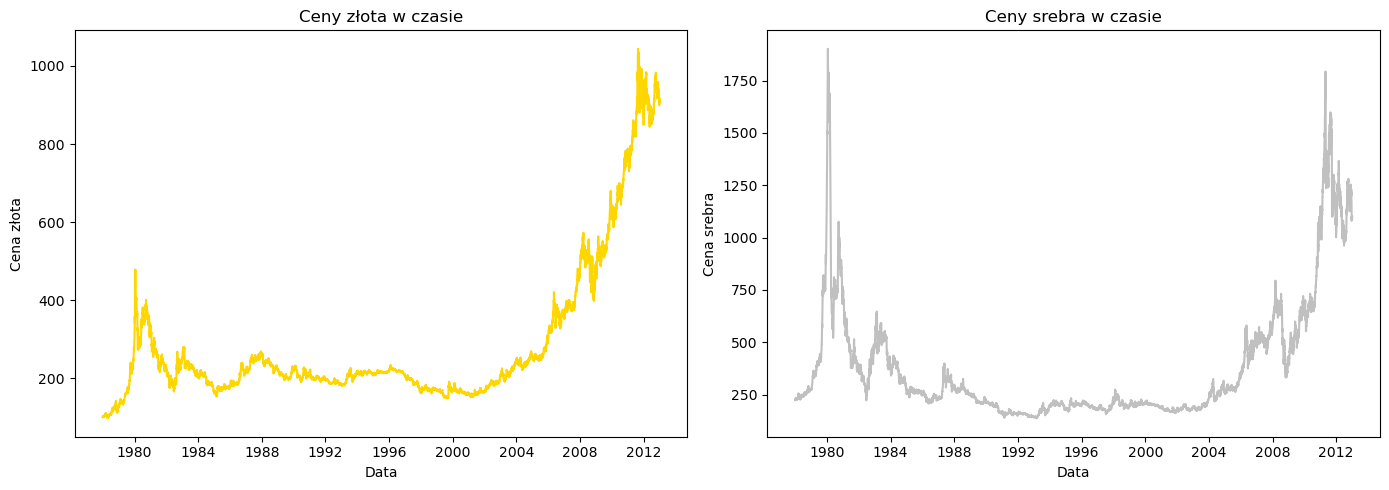

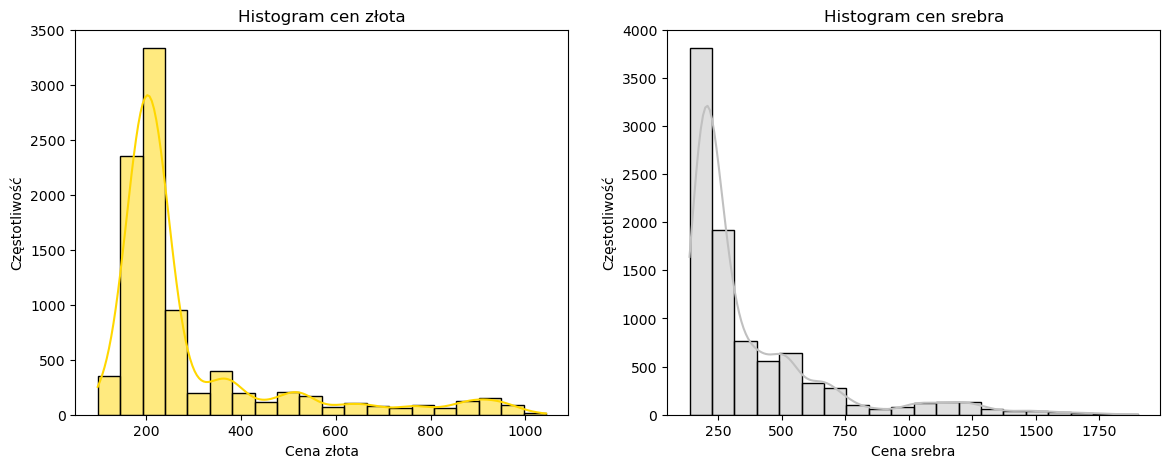

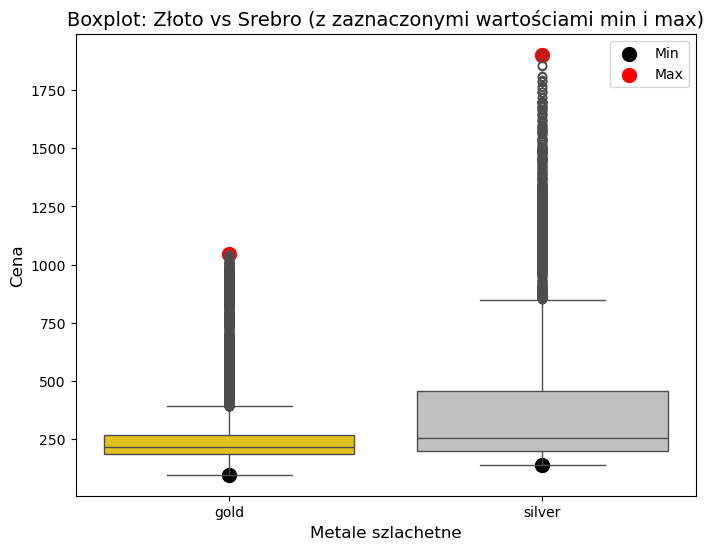

In [217]:

# Wykresy czasowe
plt.figure(figsize=(14, 5))

# Tworzymy subplot dla złota
plt.subplot(1, 2, 1)
sns.lineplot(x=df['Data'], y=df['gold'], color="gold")
plt.title("Ceny złota w czasie")
plt.xlabel("Data")
plt.ylabel("Cena złota")

# Tworzymy subplot dla srebra
plt.subplot(1, 2, 2)
sns.lineplot(x=df['Data'], y=df['silver'], color="silver")
plt.title("Ceny srebra w czasie")
plt.xlabel("Data")
plt.ylabel("Cena srebra")

plt.tight_layout()
plt.show()

# Histogramy - dla cen złota i srebra
plt.figure(figsize=(14, 5))

# Tworzymy subplot dla histogramu złota
plt.subplot(1, 2, 1)
sns.histplot(df["gold"], kde=True, bins=20, color="gold")
plt.title("Histogram cen złota")
plt.xlabel("Cena złota")
plt.ylabel("Częstotliwość")

# Tworzymy subplot dla histogramu srebra
plt.subplot(1, 2, 2)
sns.histplot(df["silver"], kde=True, bins=20, color="silver")
plt.title("Histogram cen srebra")
plt.xlabel("Cena srebra")
plt.ylabel("Częstotliwość")

plt.show()




# Tworzenie wykresu boxplot
plt.figure(figsize=(8, 6))

# Tworzymy boxplot z odpowiednimi kolorami
sns.boxplot(data=df[["gold", "silver"]], palette=["gold", "silver"])

# Dodanie wartości min i max jako punkty
min_values = df[["gold", "silver"]].min()
max_values = df[["gold", "silver"]].max()

# Zaznaczenie punktów dla min i max
plt.scatter([0, 1], min_values, color='black', marker='o', s=100, label='Min')  # Min dla złota i srebra
plt.scatter([0, 1], max_values, color='red', marker='o', s=100, label='Max')  # Max dla złota i srebra

# Dodanie tytułu i etykiet
plt.title("Boxplot: Złoto vs Srebro (z zaznaczonymi wartościami min i max)", fontsize=14)
plt.xlabel("Metale szlachetne", fontsize=12)
plt.ylabel("Cena", fontsize=12)

# Dodanie legendy
plt.legend()

# Wyświetlenie wykresu
plt.show()

# wstęp do analizy
Wykorzystany zbiór danych zawiera ceny złota i srebra na przestrzeni kilkudziesięciu lat - od 1977 roku do 2012. Dane obejmują daty oraz odpowiadające im wartości cenowe dla obu metali szlachetnych. Zbiór danych zawiera 9132 obserwacji i jest zapisany w formacie CSV, z datami w kolumnie rownames oraz cenami złota i srebra w kolumnach gold i silver. Dane pochodzą z [https://vincentarelbundock.github.io/Rdatasets/datasets.html]. Celem analizy jest zrozumienie dynamiki zmian cen złota i srebra w czasie, z uwzględnieniem różnic pomiędzy nimi.
W szczególności, analiza ma na celu:
- porównanie rozkładów cen złota i srebra na podstawie dostępnych danych (m. in. wykresy histograficzne, analiza statystyczna).
- zbadanie zmienności obu metali, co może pomóc w ocenie ich stabilności jako inwestycji.
- analiza trendów cenowych w czasie (np. czy ceny złota i srebra rosną lub maleją w danym okresie).
- ocena zależności pomiędzy cenami złota a srebra, aby sprawdzić, czy zmiany cen jednego metalu mają wpływ na ceny drugiego.

Dzięki tej analizie możliwe będzie uzyskanie cennych informacji na temat potencjalnych korelacji oraz zmienności cen złota i srebra, co może być użyteczne zarówno dla inwestorów, jak i dla analityków rynkowych.

# analiza przy pomocy metryk statystycznych
## Miary polożenia 
Miary położenia są to statystyki, które pozwalają określić, w jakim miejscu w rozkładzie znajdują się wartości danych. Każda z tych miar dostarcza informacji o „centrum” lub „rozrzuceniu” danych.
### Średnia arytmetyczna 
Definicja: Średnia arytmetyczna to suma wszystkich wartości w zbiorze danych podzielona przez liczbę obserwacji. Jest to najczęściej stosowana miara położenia, która reprezentuje typową wartość w zbiorze danych.
(wzór)

Interpretacja w kontekście danych:
Średnia cena złota w analizowanym okresie wynosiła około 287.37 jednostek walutowych.

Średnia cena srebra w analizowanym okresie wynosiła około 376.65 jednostek walutowych.

Średnia daje ogólne wyobrażenie o poziomie cen w całym okresie analizy, ale jest wrażliwa na wartości skrajne, jak bardzo wysokie ceny (np. cena maksymalna).

### Mediana
Definicja: Mediana to wartość środkowa w zbiorze danych, który został uporządkowany rosnąco. Mediana dzieli zbiór danych na dwie równe części, gdzie połowa obserwacji jest mniejsza od mediany, a połowa większa.

Interpretacja w kontekście danych:
Złoto: Mediana wynosi 215.16. Oznacza to, że połowa dni miała ceny złota poniżej tej wartości, a połowa powyżej. Wartość mediany sugeruje, że cena złota nie jest równomiernie rozłożona wokół średniej — istnieje pewna asymetria w rozkładzie cen.

Srebro: Mediana wynosi 255.36. Podobnie jak w przypadku złota, połowa dni miała ceny srebra poniżej tej wartości, a połowa powyżej.

Mediana jest bardziej odporna na wartości skrajne (outliers) niż średnia, dlatego daje bardziej reprezentatywną wartość w przypadku rozkładów asymetrycznych.

### Minimum 
Definicja: Minimum to najmniejsza wartość w zbiorze danych. Jest to miara skrajna, która informuje o najniższej cenie w analizowanym okresie.

Interpretacja w kontekście danych:

Złoto: Najniższa cena złota wynosi 97.45. Oznacza to, że cena złota w jednym z dni osiągnęła wartość 97.45, co jest najniższą ceną w całym analizowanym okresie.

Srebro: Najniższa cena srebra wynosi 137.30.

Minimum informuje o najniższym poziomie cen, ale może być wynikiem wyjątkowych okoliczności, np. nagłych zjawisk rynkowych.

### Maksimum 
Definicja: Maksimum to największa wartość w zbiorze danych. Tak jak minimum, jest to miara skrajna, która wskazuje na najwyższą cenę w analizowanym okresie.

Interpretacja w kontekście danych:

Złoto: Najwyższa cena złota wynosi 1043.89. Oznacza to, że cena złota w jednym z dni osiągnęła wartość 1043.89, co jest najwyższą ceną w całym analizowanym okresie.

Srebro: Najwyższa cena srebra wynosi 1901.93.

Maksimum informuje o najwyższych cenach, które mogą wskazywać na wyjątkowe zjawiska lub wzrosty w okresach kryzysowych.

### Średnia geometryczna

Definicja: Średnia geometryczna to średnia arytmetyczna, ale dla logarytmów wartości danych. Oblicza się ją jako pierwiastek z iloczynu wszystkich wartości w zbiorze danych. Jest szczególnie użyteczna w przypadku danych, które są wyrażone w skali procentowej lub w przypadku wartości, które różnią się o kilka rzędów wielkości.

Interpretacja w kontekście danych:

Złoto: Średnia geometryczna wynosi 249.29. Ta miara jest mniej wrażliwa na skrajne wartości niż średnia arytmetyczna, dlatego może dawać bardziej reprezentatywną wartość w przypadku rozkładów z wartościami ekstremalnymi.

Srebro: Średnia geometryczna wynosi 307.78.

Średnia geometryczna jest bardzo przydatna, kiedy dane są w formie proporcji lub logarytmów (np. zmiany procentowe), lub gdy w zbiorze występują wartości ekstremalne.

### Średnia ucinana

Definicja: Średnia ucinana (lub trimowana) to średnia, w której odrzuca się pewny procent najmniejszych i największych wartości (w tym przypadku 10%). Oznacza to, że 10% najniższych i 10% najwyższych wartości zostaje odrzuconych, a oblicza się średnią na podstawie pozostałych danych. Jest to metoda, która pozwala zminimalizować wpływ skrajnych wartości (outliers) na wynik.

Wzór: Średnia ucinana jest obliczana poprzez usunięcie pewnej części danych (np. 10% z każdej strony) i obliczenie średniej z pozostałych wartości.

Interpretacja w kontekście danych:

Złoto: Średnia ucinana (10%) wynosi 242.77. Oznacza to, że po odrzuceniu 10% najniższych i 10% najwyższych cen złota, pozostała średnia wynosi 242.77. Ta miara jest bardziej odporna na wartości skrajne, ponieważ nie bierze ich pod uwagę przy obliczaniu średniej.

Srebro: Średnia ucinana (10%) wynosi 311.86.

Średnia ucinana daje bardziej „odporną” wartość na wpływ ekstremów w danych.

### Średnia winsorowska

Definicja: Średnia Winsorowska to średnia, w której skrajne wartości (np. 10% najniższych i 10% najwyższych) nie są usuwane, lecz zamiast tego są zastępowane przez wartości skrajne w pobliżu tych granic. Zamiast usuwania danych, tak jak w przypadku średniej ucinanej, wartości ekstremalne są "przycinane" do wartości najbliższych, co pozwala na zminimalizowanie wpływu tych wartości na wynik.

Wzór: Podobnie jak średnia ucinana, ale w tym przypadku skrajne wartości są zastępowane przez wartości na granicach (np. 10% najniższych wartości zostaje zastąpione przez wartość 11-tej najniższej itd.).

Interpretacja w kontekście danych:

Złoto: Średnia Winsorowska (10%) wynosi 264.62. W tym przypadku, zamiast usuwać skrajne wartości, zostały one zastąpione przez wartości w pobliżu granic, co zmienia wartość średniej na 264.62. Jest to metoda, która pozwala na "kontrolowanie" wpływu skrajnych danych na wynik.

Srebro: Średnia Winsorowska (10%) wynosi 338.79.

Średnia Winsorowska jest podobna do średniej ucinanej, ale zamiast usuwać wartości, łagodzi ich wpływ na wynik.

### Kwartyle

Kwartyle dzielą uporządkowany zbiór danych na cztery równe części:

Q1 (1. kwartyl) – wartość, poniżej której znajduje się 25% danych

Q2 (2. kwartyl) – mediana, dzieli dane na połowę (50%)

Q3 (3. kwartyl) – wartość, poniżej której znajduje się 75% danych

Interpretacja w kontekście danych:
Złoto 
Miara	Wartość
Q1	186.38
Q2	215.16
Q3	268.37
IQR	81.99
Oznacza to, że 50% cen złota mieści się w przedziale 186.38–268.37, czyli wokół mediany.
Rozstęp międzykwartylowy (IQR) = 81.99 mówi nam, że ceny złota mają umiarkowane rozproszenie – połowa obserwacji jest oddalona od siebie średnio o ~82 jednostki.
Relatywnie wąski IQR sugeruje bardziej „zbity” rozkład cen wokół środka.

Srebro
Miara	Wartość
Q1	197.78
Q2	255.36
Q3	459.20
IQR	261.42
50% cen srebra mieści się w znacznie szerszym zakresie: 197.78–459.20, czyli mamy dużo większe zróżnicowanie.
IQR = 261.42 wskazuje na dużą zmienność cen srebra, co może świadczyć o większej niestabilności rynku lub silnych wahaniach w analizowanym okresie.

### Dominanta (moda)

Definicja:
Moda to wartość, która pojawia się najczęściej w zbiorze danych. Może być więcej niż jedna (wtedy mamy rozkład wielomodalny), albo żadna (jeśli wszystkie wartości są unikalne).

Interpretacja w kontekście danych:
Złoto: [100.00, 171.68, 185.60, 215.04]
Srebro: [200.39, 204.26]

Zarówno dla złota, jak i srebra, rozkład jest wielomodalny – istnieje kilka różnych wartości, które występują z tą samą najwyższą częstotliwością.
Może to sugerować występowanie różnych poziomów cen w określonych przedziałach czasowych – np. stabilizacja cen wokół konkretnych wartości w różnych okresach.
Nie dominuje jedna konkretna wartość, więc moda ma ograniczoną użyteczność w opisie ogólnego poziomu cen tych metali.


### Środek rozstępu (Midrange)
Definicja:
To średnia arytmetyczna wartości minimalnej i maksymalnej. Mierzy teoretyczny środek rozpiętości danych, ale jest bardzo wrażliwy na wartości odstające.

Interpretacja w kontekście danych:
Złoto: 570.67
Srebro: 1019.62

Te wartości są znacznie wyższe niż średnie i mediany → sugeruje to, że występują silne wartości maksymalne (outliery), które przesuwają środek rozstępu w górę.
Środek rozstępu nie oddaje realnego „środka” danych – nie jest odporny na skrajne obserwacje.


### Średnia harmoniczna
Definicja:
Średnia harmoniczna to odwrotność średniej odwrotności danych. Jest używana głównie przy danych, które mają sens jako wielkości odwrotne, np. ceny jednostkowe, prędkości, stopy procentowe.

Interpretacja w kontekście danych:
Złoto: 226.55
Srebro: 267.58

Średnia harmoniczna jest niższa niż średnia arytmetyczna, co jest typowe dla danych asymetrycznych prawostronnie (długie ogony z dużymi wartościami).
Jest bardziej odporna na duże wartości odstające, ale bardziej wrażliwa na wartości bardzo małe.
Pokazuje niższy „efektywny” poziom cen złota i srebra – szczególnie użyteczna, gdy chcemy ocenić typową jednostkową wartość np. z punktu widzenia inwestora.

